In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [2]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [3]:
χ_lower = 115
χ_upper = 165

Read Data

In [36]:
dataset_qua = ["OPAL", "MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    STAT = df["STAT"]
    SYS = df["SYS"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "STAT":STAT, "SYS":SYS})
    df_ss[name] = df1

dataset_names = ["SLD","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]
df = df_qua
df.update(df_ss)

#---------------------------------------------------------------------------------

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    STAT[name] = np.array(df_truncated[name]["STAT"])
    SYS[name] = np.array(df_truncated[name]["SYS"])

Q_list = {}

Q_list["TASSO_140"]=14.0
Q_list["TASSO_220"]=22.0
Q_list["TASSO_348"]=34.8
Q_list["MARKII"]   =29.0
Q_list["TASSO_435"]=43.5
Q_list["TOPAZ_533"]=53.3
Q_list["TOPAZ_595"]=59.5
Q_list["SLD"]      =91.2
Q_list["OPAL"]=91.2
Q_list["DELPHI"]=91.2

Chi-Square calculation

In [5]:
def CHI2_func(DELTA,STAT,SYS):
    ERROR = (STAT**2+SYS**2)**0.5
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [25]:
def CHI2_func(DELTA,STAT,SYS):

    #Build Error Matrix
    l = len(DELTA)
    V = np.zeros((l, l))
    for i in range(l):
        for j in range(l):
            if i == j:
                V[i, j] = (STAT[i] ** 2) + min(SYS[i] ** 2, SYS[j] ** 2)
            else:
                V[i, j] = min(SYS[i] ** 2, SYS[j] ** 2)
    V_inv = np.linalg.inv(V)

    #Calculate Chi2
    chi_squared = np.dot(DELTA, np.matmul(V_inv, DELTA))
    return chi_squared

In [27]:
def DELTA_func(ylist,PRED_ends,PRED_mid):
    PRED_ends_rm = np.nan_to_num(PRED_ends, nan=0.0)
    l = len(ylist)
    theory=np.zeros(l)
    for i in range(l):
        theory[i]=(PRED_ends_rm[i]+PRED_mid[i]+PRED_ends_rm[i+1])/3
    return theory - ylist

Define Objective

In [28]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    XLL="N3LL'"

    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist["mid"]=np.array(df[name]["CHI"])
        binsize=abs(xlist["mid"][1]-xlist["mid"][0]) # Evenly sized bins assumed
        xlist["ends"]=xlist["mid"]-binsize/2
        xlist["ends"]=np.append(xlist["ends"], xlist["mid"][-1]+binsize/2)

        ylist=np.array(df[name]["EEC"])
        STAT_list=np.array(df[name]["STAT"])
        SYS_list=np.array(df[name]["SYS"])

        l = len(xlist["mid"])
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                for quartile in ["ends","mid"]:
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters, Ω1=Ω1)
                DELTA =  DELTA_func(ylist,PRED["ends"],PRED["mid"])
            else: 
                for quartile in ["ends","mid"]:
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, Ω1=Ω1)              
                DELTA =  DELTA_func(ylist,PRED["ends"],PRED["mid"])                
        else:
            parameters = params_noαs
            if len(parameters) > 0:
                for quartile in ["ends","mid"]:
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters)                
                DELTA =  DELTA_func(ylist,PRED["ends"],PRED["mid"])               
            else: 
                for quartile in ["ends","mid"]:
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL)              
                DELTA =  DELTA_func(ylist,PRED["ends"],PRED["mid"])               

        chi_square = CHI2_func(DELTA,STAT_list,SYS_list)
        chi2 = chi2 + chi_square

    return chi2/length

Define minimization related

In [29]:
class ProgressCallback:
    def __init__(self, df, Q_list, dataset_names, if_renormalon):
        self.df = df
        self.Q_list = Q_list
        self.dataset_names = dataset_names
        self.if_renormalon = if_renormalon
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df, self.Q_list, self.dataset_names, self.if_renormalon)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [37]:
objective([0.118,0.0,0.0], df_truncated, Q_list, dataset_names, False)

11.692480064220943

In [19]:
if_renormalon = False

Global

In [14]:
bounds = [ #[ 0.11 , 0.126], # αs
           #[-0.0  , 1.0  ], # Ω1
           [-1.0  , 1.0  ], # a1
           [-1.0  , 1.0  ], # a2
           #[-1.0  , 1.0  ], # a3         
        ]

n_points = 17
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[-1.0, -1.0], [-1.0, -0.875], [-1.0, -0.75], [-1.0, -0.625], [-1.0, -0.5], [-1.0, -0.375], [-1.0, -0.25], [-1.0, -0.125], [-1.0, 0.0], [-1.0, 0.125], [-1.0, 0.25], [-1.0, 0.375], [-1.0, 0.5], [-1.0, 0.625], [-1.0, 0.75], [-1.0, 0.875], [-1.0, 1.0], [-0.875, -1.0], [-0.875, -0.875], [-0.875, -0.75], [-0.875, -0.625], [-0.875, -0.5], [-0.875, -0.375], [-0.875, -0.25], [-0.875, -0.125], [-0.875, 0.0], [-0.875, 0.125], [-0.875, 0.25], [-0.875, 0.375], [-0.875, 0.5], [-0.875, 0.625], [-0.875, 0.75], [-0.875, 0.875], [-0.875, 1.0], [-0.75, -1.0], [-0.75, -0.875], [-0.75, -0.75], [-0.75, -0.625], [-0.75, -0.5], [-0.75, -0.375], [-0.75, -0.25], [-0.75, -0.125], [-0.75, 0.0], [-0.75, 0.125], [-0.75, 0.25], [-0.75, 0.375], [-0.75, 0.5], [-0.75, 0.625], [-0.75, 0.75], [-0.75, 0.875], [-0.75, 1.0], [-0.625, -1.0], [-0.625, -0.875], [-0.625, -0.75], [-0.625, -0.625], [-0.625, -0.5], [-0.625, -0.375], [-0.625, -0.25], [-0.625, -0.125], [-0.625, 0.0], [-0.625, 0.125], [-0.625, 0.25], [-0.625, 0.375]

In [85]:
chi2_list = []
for parameters in tqdm(params):
    parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, df_truncated, Q_list, dataset_names, if_renormalon))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 289/289 [01:52<00:00,  2.56it/s]

min_chi2/dof 4.820033419497693 best_params [0.118, 0.625, 0.25]


Local then hopping

In [70]:
initial_params = [0.118,0.0,0.0] #best_params

bounds = [ [0.110 , 0.14], # αs
           #[-1.0 , 1.0  ], # Ω1
            [-3.0, 3.0  ], # a1
            [-3.0, 3.0  ], # a2
            #[-3.0, 3.0  ], # a3         
        ]

bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(df_truncated, Q_list, dataset_names, if_renormalon)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (df_truncated, Q_list, dataset_names, if_renormalon),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [0.1202947  0.23619172 0.31291398], Chi2/dof: 1.5378708773906613
Iteration: 2, Params: [0.12063375 0.29192711 0.38675475], Chi2/dof: 1.1899361081033952
Iteration: 3, Params: [0.12052481 0.29647799 0.3927854 ], Chi2/dof: 1.1871181615020976
Iteration: 4, Params: [0.1191629  0.34166381 0.45266761], Chi2/dof: 1.1678582189131126
Iteration: 5, Params: [0.11840637 0.35960524 0.47645131], Chi2/dof: 1.1592707906890176
Iteration: 6, Params: [0.11799499 0.36303924 0.4810184 ], Chi2/dof: 1.1544490187067902
Iteration: 7, Params: [0.11798096 0.36346324 0.48158257], Chi2/dof: 1.15444763001306
Iteration: 8, Params: [0.11801316 0.36181305 0.48034317], Chi2/dof: 1.1543717183174023
Iteration: 9, Params: [0.11810862 0.35378284 0.47681559], Chi2/dof: 1.1539031474713608
Iteration: 10, Params: [0.11824868 0.33291946 0.4720824 ], Chi2/dof: 1.1526373459387966
Iteration: 11, Params: [0.11839738 0.28480246 0.4683277 ], Chi2/dof: 1.1496865778338994
Iteration: 12, Params: [0.11844107 0.181721

In [132]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x000002d2c5e8db30>

Plot

In [71]:
xlist = np.pi/180*np.linspace(χ_lower,180, 100, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    if if_renormalon: 
        Ω1 = params_noαs[0]
        parameters = params_noαs[1:]  
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", parameters=parameters, Ω1=Ω1)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", Ω1=Ω1)            
    else:
        parameters = params_noαs
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", parameters=parameters)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'")      

    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

[-0.18448315  0.57547696]


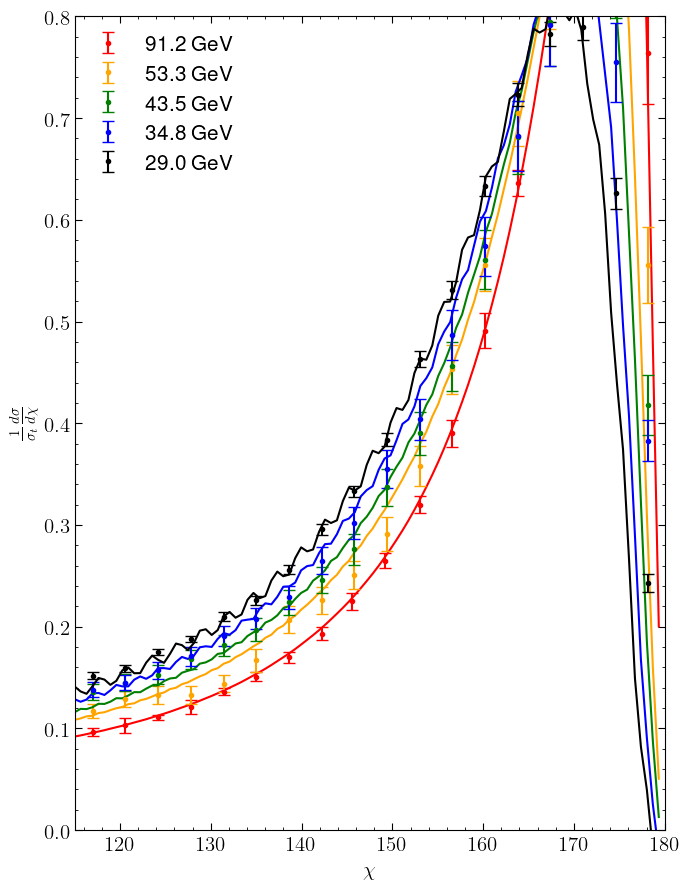

In [72]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,0.8)
plt.xlim(χ_lower,180)

plt.tight_layout()  
plt.show()

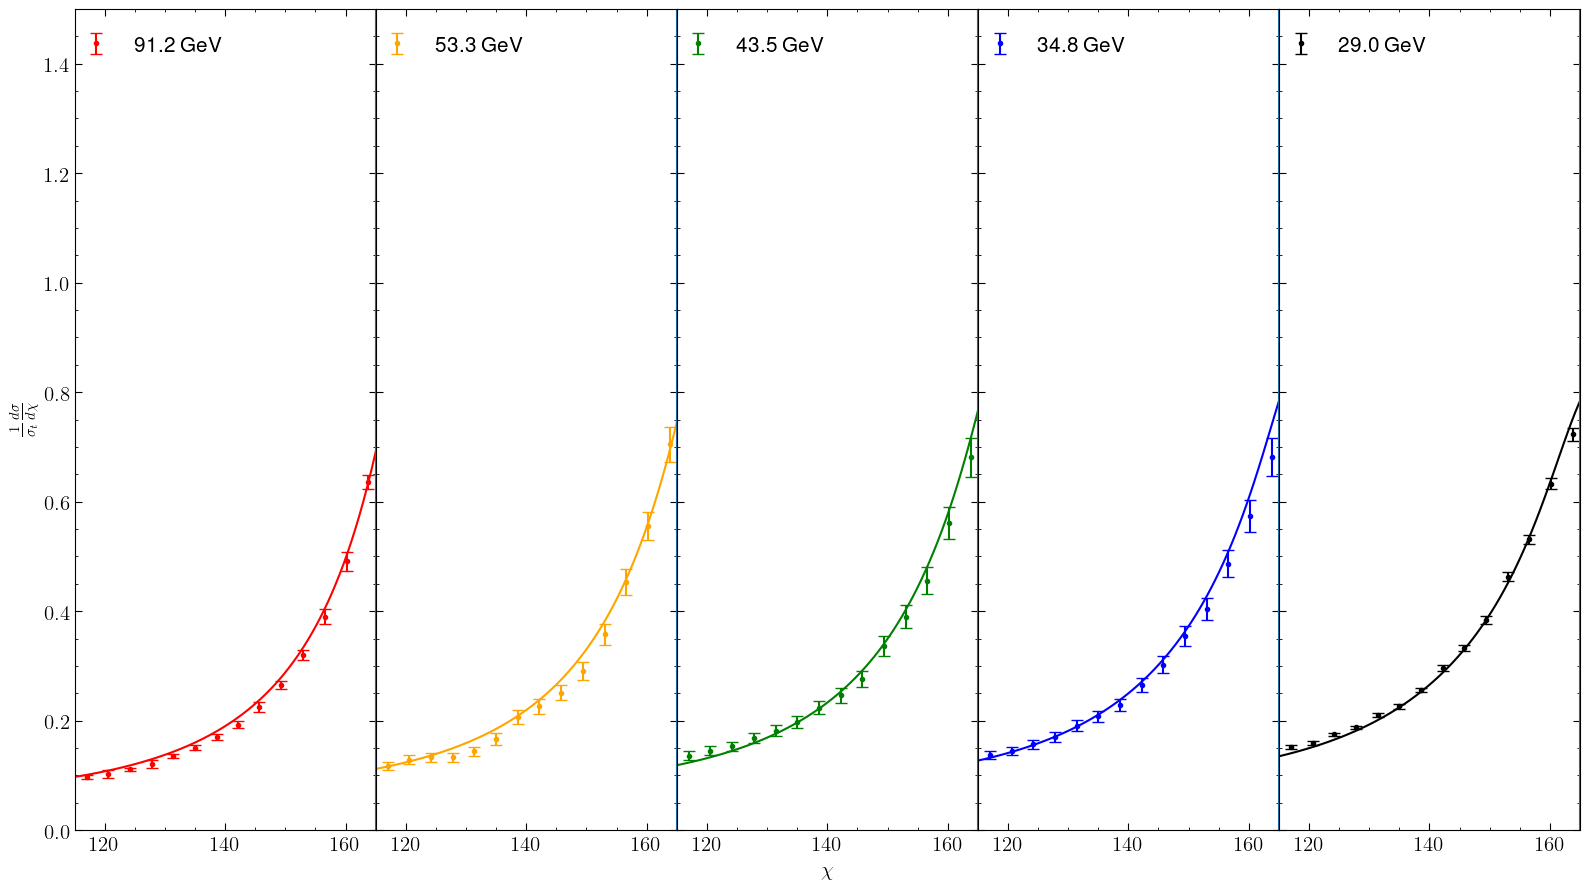

In [67]:
fig, [ax1,ax2,ax3,ax4,ax5] = plt.subplots(1, 5, figsize=(16, 9),sharex=True, sharey=True) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
ax_list = [ax1,ax2,ax3,ax4,ax5]

i=0
for name in dataset_names:
    ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax3.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.55, 0.99))
    ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0, 1.5)
plt.xlim(χ_lower,χ_upper)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

Old method

In [68]:
chi2 = 0
length = 0

chi2_list = {}
params=optimal_params

XLL="N3LL'"

chi2 = 0
length = 0
    
αs = params[0]
params_noαs = params[1:]

for name in dataset_names:

    xlist=χ[name]
    ylist=EEC[name]
    errlist=ERROR[name]

    residuals=[]
    l = len(xlist)
    length = length + l

    if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters, Ω1=Ω1) - ylist)/errlist
            else: 
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, Ω1=Ω1) - ylist)/errlist
    else:
            parameters = params_noαs
            if len(parameters) > 0:
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters) - ylist)/errlist
            else: 
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL) - ylist)/errlist 

    chi_square = np.sum(np.square(residuals))
    chi2 = chi2 + chi_square
    chi2_list[name] = chi_square/l

display(chi2_list)
display(chi2/length)

{'SLD': 2.901072660905855,
 'TOPAZ_533': 1.5957829670137718,
 'TASSO_435': 0.7788150986370154,
 'TASSO_348': 0.6510279524414987,
 'MARKII': 3.530019664523927}

1.8913436687044136

New method

In [69]:
chi2_list = {}

chi2=0
length=0

for name in dataset_names:
    l = len(df_truncated[name]["CHI"])
    length=length+l
    chi2_dof = objective(optimal_params, df_truncated, Q_list, [name], False)
    chi2_list[name] = chi2_dof
    chi2 = chi2 + chi2_dof*l
display(chi2_list)
display(chi2/length)

{'SLD': 2.7691276704777685,
 'TOPAZ_533': 1.3668656104093595,
 'TASSO_435': 0.6471576854701374,
 'TASSO_348': 0.9502153717359544,
 'MARKII': 2.628431888417764}

1.6723596453021967

In [23]:
average_error={}

for name in dataset_names:
    l = len(xlist)
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'SLD': 0.0033,
 'TOPAZ_533': 0.0062,
 'TASSO_435': 0.0062,
 'TASSO_348': 0.0057,
 'MARKII': 0.002}